# Punkt IV — Expected Exposure dla IRS (poprawiona implementacja)

**Projekt CVA UEP — Spring 2026, data obliczeniowa: 31.12.2025**

## Zakres
1. Kalibracja ABM (EURIBOR 3M) i GBM (EURPLN) na **wspólnym oknie 2025**
2. Estymacja korelacji ρ między innowacjami obu procesów
3. **Joint simulation** z dekompozycją Cholesky'ego (3y horyzont, krok 1M, 10 000 ścieżek)
4. Wycena MtM dla:
   - Receiver IRS EUR EURIBOR 3M (fixed 2.02% rocznie / floating kwartalnie) 
   - FX Forward Buy EUR Sell PLN (notional 1M EUR, strike 4.4439, T=3y)
5. Profile EE i PFE — pojedynczo i na poziomie portfela w PLN

## Konwencje metodologiczne
- **ABM driftless (μ=0)** dla EURIBOR 3M — konwencja spójna z miarą forward i płaską krzywą dyskonta r_EUR=2%. 
  Fizyczny drift z 2025 (–71.86 bps/rok) zostanie pokazany w sensitivity.
- **GBM dla EURPLN** z risk-neutral driftem r_PLN − r_EUR (= ln(K/S₀)/T = 1.67%, implikowane z forwardu 4.4439).
- **Korelacja** estymowana między dziennymi przyrostami EURIBOR (Δr) i log-zwrotami EURPLN (ΔlnS) na wspólnym oknie 2025.
- **Płaska krzywa EUR** r_EUR = 2% (≈ ESTR), płaska krzywa PLN r_PLN ≈ 3.67% — implikowane z notowań forwardu.
- **Reset floating leg**: stopa fixowana w T_{n−1}, używana dla okresu [T_{n−1}, T_n]. W siatce dt=1/12 daty resetów (co 0.25y) leżą dokładnie na węzłach.

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import urllib.request, json

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 100

In [ ]:
# --- EURIBOR 3M ---
df_ir = pd.read_excel('euribor.xlsx', sheet_name='euribor')
df_ir['date'] = pd.to_datetime(df_ir['Date'], format='%d %b %Y')
df_ir = (df_ir[['date', '3_month']]
         .rename(columns={'3_month': 'euribor3m'})
         .assign(euribor3m=lambda d: d['euribor3m']/100)
         .sort_values('date').reset_index(drop=True))

# --- EURPLN z API NBP (kurs średni, tabela A) ---
def fetch_nbp_eur(start, end):
    url = f'https://api.nbp.pl/api/exchangerates/rates/A/EUR/{start}/{end}/?format=json'
    with urllib.request.urlopen(url, timeout=20) as r:
        return json.loads(r.read())['rates']

rates = []
for s, e in [('2025-01-02','2025-04-30'),('2025-05-01','2025-08-31'),('2025-09-01','2025-12-31')]:
    rates.extend(fetch_nbp_eur(s, e))
df_fx = (pd.DataFrame(rates)
         .assign(date=lambda d: pd.to_datetime(d['effectiveDate']))
         [['date', 'mid']].rename(columns={'mid': 'eurpln'})
         .sort_values('date').reset_index(drop=True))

# --- Wspólne okno 2025 ---
df_ir_2025 = df_ir[(df_ir['date'] >= '2025-01-01') & (df_ir['date'] <= '2025-12-31')]
df_fx_2025 = df_fx[(df_fx['date'] >= '2025-01-01') & (df_fx['date'] <= '2025-12-31')]
merged = pd.merge(df_fx_2025, df_ir_2025, on='date', how='inner').sort_values('date').reset_index(drop=True)

print(f"EURIBOR 3M (2025): {len(df_ir_2025)} obserwacji")
print(f"EURPLN (2025):     {len(df_fx_2025)} obserwacji")
print(f"Wspólne dni:       {len(merged)} obserwacji")
print(f"Zakres:            {merged['date'].iloc[0].date()} -> {merged['date'].iloc[-1].date()}")
print(f"\nNa 31.12.2025:  EURIBOR 3M = {merged['euribor3m'].iloc[-1]*100:.4f}%   EURPLN = {merged['eurpln'].iloc[-1]:.4f}")

EURIBOR 3M (2025): 254 obserwacji
EURPLN (2025):     251 obserwacji
Wspólne dni:       250 obserwacji
Zakres:            2025-01-02 -> 2025-12-31

Na 31.12.2025:  EURIBOR 3M = 2.0260%   EURPLN = 4.2267


Kalibracja modeli i estymacja korelacji

**ABM dla EURIBOR 3M**:  
$dr(t) = \mu\,dt + \sigma\,dW(t)$

Kalibrujemy z dziennych **przyrostów** $\Delta r_t = r_t - r_{t-1}$:
- $\hat{\sigma}_{annual} = \sigma_{daily}\sqrt{252}$
- $\hat{\mu}_{annual} = \bar{\Delta r}\cdot 252$

**GBM dla EURPLN**:  
$dS(t) = \mu S(t)\,dt + \sigma S(t)\,dW(t)$

Kalibrujemy z dziennych **log-zwrotów** $\Delta \ln S_t$:
- $\hat{\sigma}_{annual} = \sigma_{daily}\sqrt{252}$

**Korelacja** estymowana między $\Delta r_t$ a $\Delta \ln S_t$ na **dokładnie tych samych dniach** 

In [61]:
ir = merged['euribor3m'].values
fx = merged['eurpln'].values
delta_r = np.diff(ir)
log_ret_fx = np.diff(np.log(fx))

# Kalibracja ABM
sigma_ir = delta_r.std(ddof=1) * np.sqrt(252)
mu_ir_phys = delta_r.mean() * 252  # fizyczny drift (P-measure)

# Kalibracja GBM
sigma_fx = log_ret_fx.std(ddof=1) * np.sqrt(252)
mu_fx_phys = log_ret_fx.mean() * 252

rho_corr, rho_pvalue = stats.pearsonr(log_ret_fx, delta_r)

# Punkty startowe na 31.12.2025
r0 = ir[-1]
S0 = fx[-1]

print("="*68)
print("KALIBRACJA na wspólnym oknie 2025 (n = {} obserwacji innowacji)".format(len(delta_r)))
print("="*68)
print(f"\n  EURIBOR 3M (ABM):")
print(f"    sigma          = {sigma_ir*10000:>8.2f} bps/rok  ({sigma_ir*100:.4f}%)")
print(f"    mu (physical)  = {mu_ir_phys*10000:>8.2f} bps/rok  (do CVA użyjemy mu=0)")
print(f"    r0 (31.12.25)  = {r0*100:>8.4f}%")
print(f"\n  EURPLN (GBM):")
print(f"    sigma          = {sigma_fx*100:>8.4f}%/rok")
print(f"    mu (physical)  = {mu_fx_phys*100:>8.4f}%/rok  (do CVA użyjemy r_PLN-r_EUR)")
print(f"    S0 (31.12.25)  = {S0:>8.4f}")
print(f"\n  Korelacja:")
print(f"    rho            = {rho_corr:>8.4f}")


KALIBRACJA na wspólnym oknie 2025 (n = 249 obserwacji innowacji)

  EURIBOR 3M (ABM):
    sigma          =    27.91 bps/rok  (0.2791%)
    mu (physical)  =   -71.86 bps/rok  (do CVA użyjemy mu=0)
    r0 (31.12.25)  =   2.0260%

  EURPLN (GBM):
    sigma          =   4.2919%/rok
    mu (physical)  =  -0.9556%/rok  (do CVA użyjemy r_PLN-r_EUR)
    S0 (31.12.25)  =   4.2267

  Korelacja:
    rho            =   0.0225


In [62]:
# Kontrakty
T_years     = 3.0
K_fwd       = 4.4439
fixed_rate  = 0.0202
notional_fx = 1_000_000
notional_ir = 10_000_000

r_EUR = 0.02
r_PLN = r_EUR + np.log(K_fwd/S0)/T_years

print(f"r_EUR = {r_EUR*100:.4f}%")
print(f"r_PLN = {r_PLN*100:.4f}%")
print(f"Spread r_PLN - r_EUR = {(r_PLN-r_EUR)*100:.4f}%")

r_EUR = 2.0000%
r_PLN = 3.6704%
Spread r_PLN - r_EUR = 1.6704%


1. Macierz korelacji $\rho_{matrix} = \begin{bmatrix} 1 & \rho \\ \rho & 1 \end{bmatrix}$
2. Dekompozycja Cholesky'ego: $L L^T = \rho_{matrix}$
3. W każdym kroku $i$: losujemy niezależne $Z_{indep} \sim \mathcal{N}(0, I_2)$, korelujemy: $Z_{corr} = L \cdot Z_{indep}$

- ABM (EURIBOR), Euler-Maruyama (= exact, bo SDE liniowa): $r_{t+\Delta t} = r_t + \mu_{IR}\Delta t + \sigma_{IR}\sqrt{\Delta t}\,Z_{IR}$

Z μ_IR = 0 (driftless ABM).

In [63]:
# Parametry symulacji
dt          = 1/12
n_steps     = int(T_years / dt)
n_sim       = 10_000
time_grid   = np.linspace(0, T_years, n_steps + 1)

mu_ir_sim = 0.0
mu_fx_sim = r_PLN - r_EUR

rho = rho_corr
corr_matrix = np.array([[1.0, rho], [rho, 1.0]])
L = np.linalg.cholesky(corr_matrix)

print("Macierz korelacji:")
print(corr_matrix)
print("\nDekompozycja Cholesky'ego L (L @ L.T = corr_matrix):")
print(L)
print("\nWeryfikacja L @ L.T:")
print(L @ L.T)

# Symulacja
np.random.seed(42)
r_paths  = np.zeros((n_steps + 1, n_sim));  r_paths[0]  = r0
fx_paths = np.zeros((n_steps + 1, n_sim));  fx_paths[0] = S0

for i in range(1, n_steps + 1):
    Z_indep = np.random.standard_normal((2, n_sim))   # 2 x n_sim niezależnych N(0,1)
    Z_corr  = L @ Z_indep
    Z_fx, Z_ir = Z_corr[0], Z_corr[1]
    fx_paths[i] = fx_paths[i-1] * np.exp((mu_fx_sim - 0.5*sigma_fx**2)*dt + sigma_fx*np.sqrt(dt)*Z_fx)
    r_paths[i]  = r_paths[i-1]  + mu_ir_sim*dt + sigma_ir*np.sqrt(dt)*Z_ir

# Sanity check: korelacja empiryczna w symulacji
log_ret_fx_sim = np.diff(np.log(fx_paths), axis=0).flatten()
delta_r_sim    = np.diff(r_paths, axis=0).flatten()
rho_emp = np.corrcoef(log_ret_fx_sim, delta_r_sim)[0, 1]

print(f"\nSanity check: korelacja empiryczna w symulacji = {rho_emp:.4f}  (target: {rho:.4f})")
print(f"Liczba ścieżek: {n_sim:,}, kroków: {n_steps}, dt = {dt:.4f} ({dt*12:.0f} mies.)")

Macierz korelacji:
[[1.     0.0225]
 [0.0225 1.    ]]

Dekompozycja Cholesky'ego L (L @ L.T = corr_matrix):
[[1.     0.    ]
 [0.0225 0.9997]]

Weryfikacja L @ L.T:
[[1.     0.0225]
 [0.0225 1.    ]]

Sanity check: korelacja empiryczna w symulacji = 0.0209  (target: 0.0225)
Liczba ścieżek: 10,000, kroków: 36, dt = 0.0833 (1 mies.)


5. Wycena MtM

5.1 Receiver IRS EUR EURIBOR 3M


- **Fixed leg** (otrzymujemy): kupon 2.02% × N × 1.0 płatny rocznie w T = 1, 2, 3
- **Floating leg** (płacimy): kupon EURIBOR3M(T_{n−1}) × N × 0.25 płatny kwartalnie w T = 0.25, 0.5, ..., 3.0

$\text{MtM}_{IRS}(t) = \text{PV}_{fixed}(t) - \text{PV}_{float}(t)$

$\text{PV}_{fixed}(t) = K \cdot N \sum_{T_n > t} \tau \cdot DF(t, T_n)$

$\text{PV}_{float}(t) = N \sum_{T_n > t} r(T_{n-1}) \cdot 0.25 \cdot DF(t, T_n)$

In [81]:
fixed_dates = np.array([1.0, 2.0, 3.0])
float_dates = np.array([(k+1)*0.25 for k in range(12)])
tau_fixed   = 1.0
tau_float   = 0.25

def DF_eur(tau): return np.exp(-r_EUR * tau)
def DF_pln(tau): return np.exp(-r_PLN * tau)
def grid_idx(t): return int(round(t / dt))

MtM_IRS = np.zeros((n_steps + 1, n_sim))  # w EUR

for i in range(n_steps + 1):
    t_now = time_grid[i]
    
    # Fixed leg (otrzymujemy)
    pv_fixed = np.zeros(n_sim)
    for T_n in fixed_dates:
        if T_n > t_now:
            pv_fixed += fixed_rate * notional_ir * tau_fixed * DF_eur(T_n - t_now)
    
    # Floating leg (płacimy)
    pv_float = np.zeros(n_sim)
    for T_n in float_dates:
        if T_n > t_now:
            T_reset = T_n - tau_float
            idx_reset = grid_idx(T_reset)
            r_fixing = r_paths[idx_reset]
            pv_float += r_fixing * notional_ir * tau_float * DF_eur(T_n - t_now)
    
    MtM_IRS[i] = pv_fixed - pv_float

print(f"Sanity check: MtM_IRS(0) = {np.mean(MtM_IRS[0]):>12,.2f} EUR")
print(f"  (oczekiwane ~0; różnica wynika z fixed=2.02% vs r0=2.026%)")

Sanity check: MtM_IRS(0) =    -6,152.27 EUR
  (oczekiwane ~0; różnica wynika z fixed=2.02% vs r0=2.026%)


Profile Expected Exposure (EE) i PFE

In [68]:
exp_irs    = MtM_IRS.mean(axis=1)
EE_irs    = np.maximum(0, exp_irs)
PFE95_irs  = np.percentile(MtM_IRS, 95, axis=1)

print("=== Profil EE/PFE — IRS standalone (EUR) ===")
print(f"{'t [y]':>6} {'EE [EUR]':>14} {'PFE95 [EUR]':>14}")
for i in range(0, n_steps+1, 3):
    print(f"{time_grid[i]:>6.2f} {EE_irs[i]:>14,.0f} {PFE95_irs[i]:>14,.0f}")
print(f"{time_grid[-1]:>6.2f} {EE_irs[-1]:>14,.0f} {PFE95_irs[-1]:>14,.0f}")

peak = np.argmax(EE_irs)
print(f"\nPeak EE: {EE_irs[peak]:,.0f} EUR przy t = {time_grid[peak]:.2f}y")
print(f"\nPeak PFE95: {PFE95_irs[np.argmax(PFE95_irs)]:,.0f} EUR przy t = {time_grid[peak]:.2f}y")

=== Profil EE/PFE — IRS standalone (EUR) ===
 t [y]       EE [EUR]    PFE95 [EUR]
  0.00              0        116,762
  0.25         44,467        167,997
  0.50         95,355        217,106
  0.75        146,496        263,370
  1.00              0        106,949
  1.25         46,615        149,916
  1.50         97,567        190,134
  1.75        148,722        229,102
  2.00              0         65,481
  2.25         48,723        101,599
  2.50         99,556        136,165
  2.75        150,607        169,579
  3.00              0              0
  3.00              0              0

Peak EE: 151,110 EUR przy t = 2.92y

Peak PFE95: 264,250 EUR przy t = 2.92y


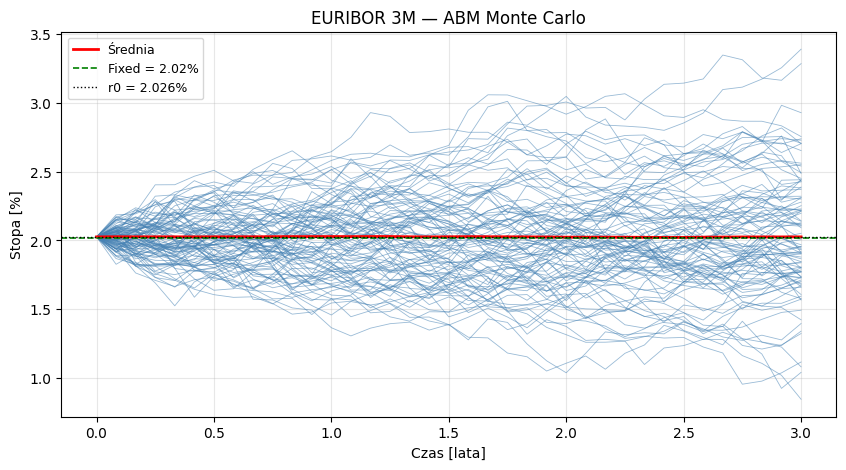

In [ ]:
plt.figure(figsize=(10, 5))
for j in range(100):    
    plt.plot(time_grid, r_paths[:, j]*100, color='steelblue', alpha=0.55, lw=0.6)
plt.plot(time_grid, r_paths.mean(axis=1)*100, color='red', lw=2, label='Średnia')
plt.axhline(fixed_rate*100, color='green', ls='--', lw=1.2, label=f'Fixed = {fixed_rate*100:.2f}%')
plt.axhline(r0*100, color='black', ls=':', lw=1, label=f'r0 = {r0*100:.3f}%')
plt.title('EURIBOR 3M — ABM Monte Carlo')
plt.xlabel('Czas [lata]'); plt.ylabel('Stopa [%]')
plt.legend(loc='best', fontsize=9); plt.grid(True, alpha=0.3)

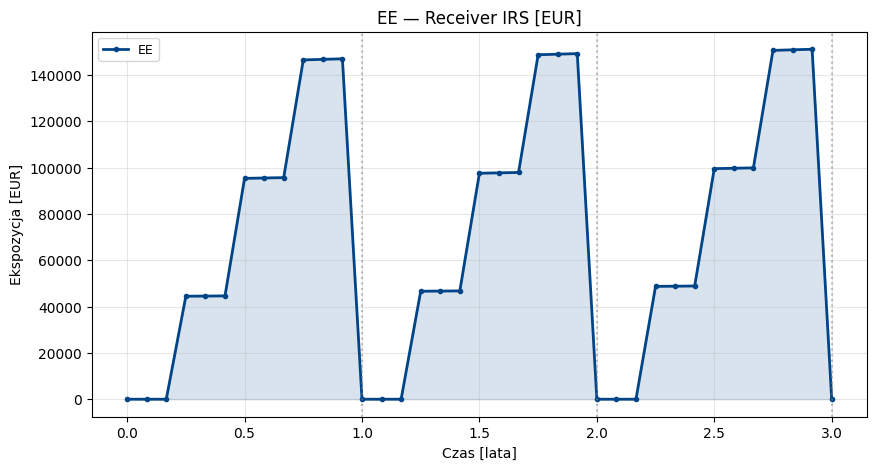

In [85]:
plt.figure(figsize=(10, 5))
plt.plot(time_grid, EE_irs, color='#004488', lw=2, marker='o', ms=3, label='EE')
plt.fill_between(time_grid, EE_irs, color='#004488', alpha=0.15)
for T in [1, 2, 3]:
    plt.axvline(T, color='gray', ls=':', alpha=0.5)
plt.title('EE — Receiver IRS [EUR]')
plt.xlabel('Czas [lata]'); plt.ylabel('Ekspozycja [EUR]')
plt.legend(loc='best', fontsize=9); plt.grid(True, alpha=0.3)